In [1]:
import pandas as pd

In [2]:
column_names = [
    'checking_account','duration','credit_history','purpose',
    'credit_amount','savings_account','employment','installment_rate',
    'personal_status','other_debtors','residence_since','property',
    'age','other_installments','housing','existing_credits','job',
    'dependents','telephone','foreign_worker','target'
]

In [3]:
df = pd.read_csv('/Users/gouric/Data/AIG/ai-governance-architect-lab/data/german.data', sep=' ', names=column_names)

In [4]:
print(df.shape)
print(df.dtypes)
print(df.head())

(1000, 21)
checking_account      object
duration               int64
credit_history        object
purpose               object
credit_amount          int64
savings_account       object
employment            object
installment_rate       int64
personal_status       object
other_debtors         object
residence_since        int64
property              object
age                    int64
other_installments    object
housing               object
existing_credits       int64
job                   object
dependents             int64
telephone             object
foreign_worker        object
target                 int64
dtype: object
  checking_account  duration credit_history purpose  credit_amount  \
0              A11         6            A34     A43           1169   
1              A12        48            A32     A43           5951   
2              A14        12            A34     A46           2096   
3              A11        42            A32     A42           7882   
4              A

In [5]:
print(df.isnull().sum())

checking_account      0
duration              0
credit_history        0
purpose               0
credit_amount         0
savings_account       0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence_since       0
property              0
age                   0
other_installments    0
housing               0
existing_credits      0
job                   0
dependents            0
telephone             0
foreign_worker        0
target                0
dtype: int64


In [6]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(2))

target
1    700
2    300
Name: count, dtype: int64
target
1    0.7
2    0.3
Name: proportion, dtype: float64


Looking at the dataset, I noticed it uses coded values like A11, A34, A93 instead of human-readable labels. For example, the first record has A93 for personal status, which actually means "male: single" but just looking at the raw data, I had no idea what that meant. That's when I decided I needed to decode the important columns before going any further.

Here's my reasoning:

**Conceptual soundness (SR 11-7):** SR 11-7 requires me to demonstrate that I understand what my model is doing. If my SHAP plot shows personal_status: A93 as a top feature, that tells nobody anything. But if it shows personal_status: male_single, now it's meaningful and auditable. I can't justify a model I can't explain in plain terms.

**Fairness analysis:** I'm going to analyse bias across personal_status and foreign_worker. I simply cannot do that properly with codes — I need to know which group is which before I can say anything meaningful about fairness.

**Model documentation:** My governance documents need to explain features in plain language. A reviewer reading checking_account: A11 learns nothing. checking_account: less_than_0_DM actually tells a story.

**Real-world practice:** In actual model risk work, you'd always map coded variables to meaningful labels before analysis. This is the professional standard, and I want to follow it from the start.

**The cost matrix — something I decided I couldn't ignore**

I also noticed point 8 in the documentation:

- Classifying a BAD customer as GOOD costs **5**
- Classifying a GOOD customer as BAD costs **1**

This stood out to me as a major governance point. A false negative i.e. missing a bad customer is 5x more costly than a false positive. Standard accuracy metrics ignore this completely, which means if I relied on accuracy alone, I'd be evaluating my model against the wrong objective. I decided to keep this in mind and account for it during model evaluation, since this connects directly to SR 11-7's outcome analysis requirements.

In [7]:
# Decode categorical columns using the data dictionary
checking_account_map = {
    'A11': 'less_than_0_DM',
    'A12': '0_to_200_DM',
    'A13': 'over_200_DM_or_salary',
    'A14': 'no_checking_account'
}

credit_history_map = {
    'A30': 'no_credits_all_paid',
    'A31': 'all_credits_paid_duly',
    'A32': 'existing_credits_paid',
    'A33': 'delay_in_past',
    'A34': 'critical_account'
}

purpose_map = {
    'A40': 'car_new', 'A41': 'car_used', 'A42': 'furniture',
    'A43': 'radio_tv', 'A44': 'domestic_appliances', 'A45': 'repairs',
    'A46': 'education', 'A48': 'retraining', 'A49': 'business', 'A410': 'others'
}

savings_account_map = {
    'A61': 'less_than_100_DM', 'A62': '100_to_500_DM',
    'A63': '500_to_1000_DM', 'A64': 'over_1000_DM', 'A65': 'unknown_no_savings'
}

employment_map = {
    'A71': 'unemployed', 'A72': 'less_than_1yr',
    'A73': '1_to_4_yrs', 'A74': '4_to_7_yrs', 'A75': 'over_7_yrs'
}

personal_status_map = {
    'A91': 'male_divorced', 'A92': 'female_divorced_married',
    'A93': 'male_single', 'A94': 'male_married', 'A95': 'female_single'
}

other_debtors_map = {
    'A101': 'none', 'A102': 'co_applicant', 'A103': 'guarantor'
}

property_map = {
    'A121': 'real_estate', 'A122': 'life_insurance',
    'A123': 'car_or_other', 'A124': 'no_property'
}

other_installments_map = {
    'A141': 'bank', 'A142': 'stores', 'A143': 'none'
}

housing_map = {
    'A151': 'rent', 'A152': 'own', 'A153': 'free'
}

job_map = {
    'A171': 'unemployed_non_resident', 'A172': 'unskilled_resident',
    'A173': 'skilled_employee', 'A174': 'management_self_employed'
}

telephone_map = {'A191': 'none', 'A192': 'yes'}
foreign_worker_map = {'A201': 'yes', 'A202': 'no'}
target_map = {1: 1, 2: 0}

# Apply all mappings
df['checking_account']    = df['checking_account'].map(checking_account_map)
df['credit_history']      = df['credit_history'].map(credit_history_map)
df['purpose']             = df['purpose'].map(purpose_map)
df['savings_account']     = df['savings_account'].map(savings_account_map)
df['employment']          = df['employment'].map(employment_map)
df['personal_status']     = df['personal_status'].map(personal_status_map)
df['other_debtors']       = df['other_debtors'].map(other_debtors_map)
df['property']            = df['property'].map(property_map)
df['other_installments']  = df['other_installments'].map(other_installments_map)
df['housing']             = df['housing'].map(housing_map)
df['job']                 = df['job'].map(job_map)
df['telephone']           = df['telephone'].map(telephone_map)
df['foreign_worker']      = df['foreign_worker'].map(foreign_worker_map)
df['target']              = df['target'].map(target_map)

print(df.head())

      checking_account  duration         credit_history    purpose  \
0       less_than_0_DM         6       critical_account   radio_tv   
1          0_to_200_DM        48  existing_credits_paid   radio_tv   
2  no_checking_account        12       critical_account  education   
3       less_than_0_DM        42  existing_credits_paid  furniture   
4       less_than_0_DM        24          delay_in_past    car_new   

   credit_amount     savings_account  employment  installment_rate  \
0           1169  unknown_no_savings  over_7_yrs                 4   
1           5951    less_than_100_DM  1_to_4_yrs                 2   
2           2096    less_than_100_DM  4_to_7_yrs                 2   
3           7882    less_than_100_DM  4_to_7_yrs                 2   
4           4870    less_than_100_DM  1_to_4_yrs                 3   

           personal_status other_debtors  ...        property age  \
0              male_single          none  ...     real_estate  67   
1  female_divorced_m

In [8]:
print(df.isnull().sum())  # should still be all zeros
print(df['personal_status'].value_counts())  # check decoding worked
print(df['foreign_worker'].value_counts())

checking_account      0
duration              0
credit_history        0
purpose               0
credit_amount         0
savings_account       0
employment            0
installment_rate      0
personal_status       0
other_debtors         0
residence_since       0
property              0
age                   0
other_installments    0
housing               0
existing_credits      0
job                   0
dependents            0
telephone             0
foreign_worker        0
target                0
dtype: int64
personal_status
male_single                548
female_divorced_married    310
male_married                92
male_divorced               50
Name: count, dtype: int64
foreign_worker
yes    963
no      37
Name: count, dtype: int64


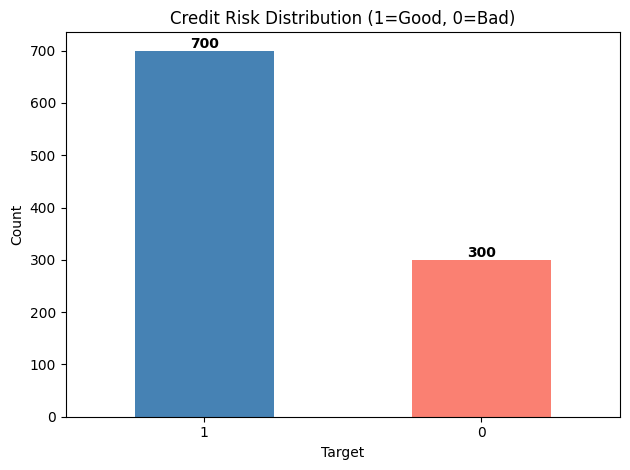

In [9]:
#Distribution of target (class balance)
import matplotlib.pyplot as plt
import seaborn as sns

df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Credit Risk Distribution (1=Good, 0=Bad)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add count labels on each bar
for i, v in enumerate(df['target'].value_counts()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

This chart shows the split between good (1) and bad (0) credit risk customers. I found 700 good customers and 300 bad ones, so a 70/30 split.
That imbalance matters more than it might look at first. A model trained on this data will naturally lean towards predicting "good" because that's what it sees most of the time. If I used accuracy alone, a model that just predicted everyone as good would score 70% and look fine on paper, but it would be completely useless in practice.
This is exactly why SR 11-7 pushes beyond simple accuracy. Metrics like KS and Gini are designed to handle situations like this, and I'll be getting into those in Week 2.

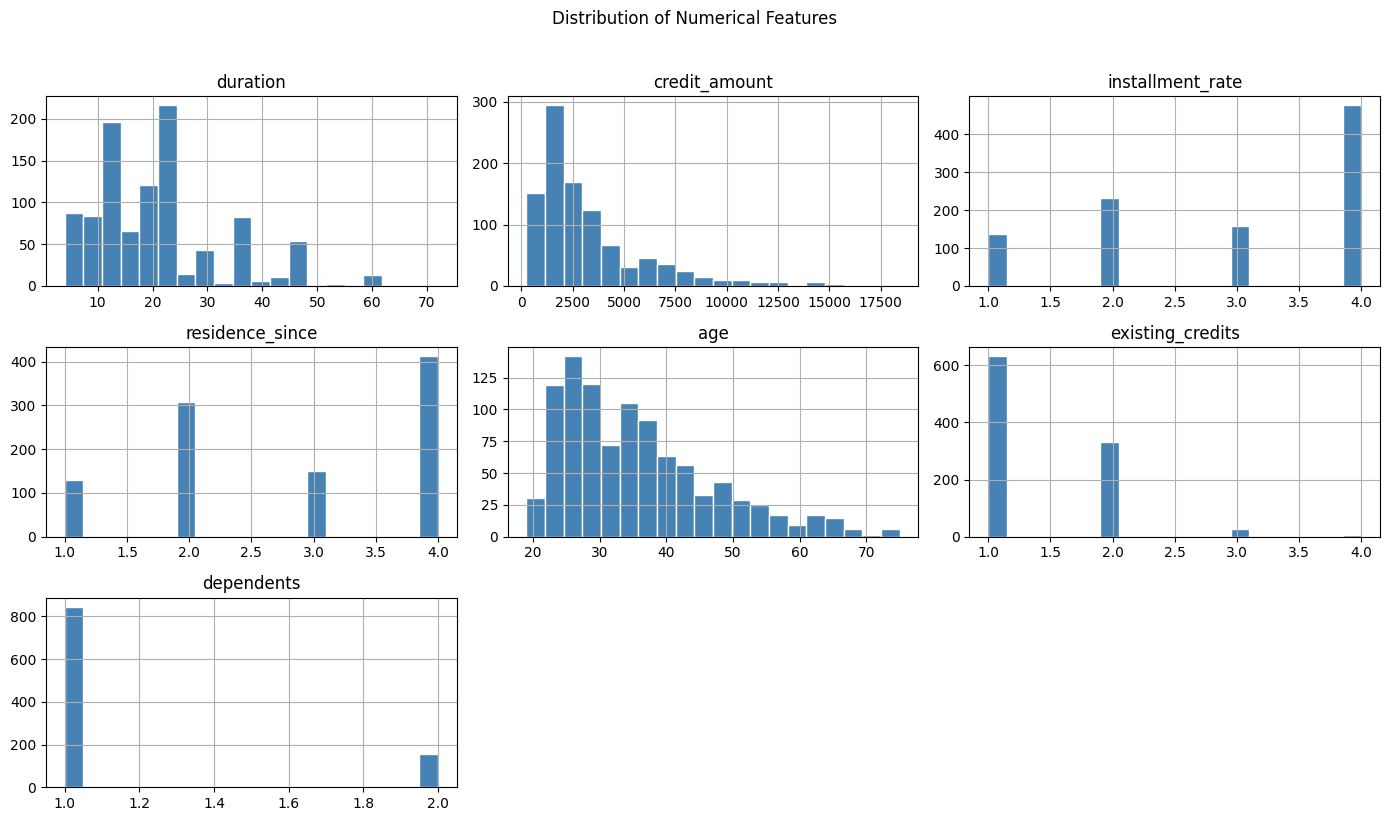

       duration  credit_amount  installment_rate  residence_since      age  \
count   1000.00        1000.00           1000.00          1000.00  1000.00   
mean      20.90        3271.26              2.97             2.84    35.55   
std       12.06        2822.74              1.12             1.10    11.38   
min        4.00         250.00              1.00             1.00    19.00   
25%       12.00        1365.50              2.00             2.00    27.00   
50%       18.00        2319.50              3.00             3.00    33.00   
75%       24.00        3972.25              4.00             4.00    42.00   
max       72.00       18424.00              4.00             4.00    75.00   

       existing_credits  dependents  
count           1000.00     1000.00  
mean               1.41        1.16  
std                0.58        0.36  
min                1.00        1.00  
25%                1.00        1.00  
50%                1.00        1.00  
75%                2.00        

In [10]:
#Distribution of numerical features
numerical_cols = ['duration', 'credit_amount', 'installment_rate', 
                  'residence_since', 'age', 'existing_credits', 'dependents']

df[numerical_cols].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats instead of count on charts (more useful for histograms)
print(df[numerical_cols].describe().round(2))

Looking at the histograms, I could see the shape of each numerical column.

**Duration** came out right-skewed. Most loans are short-term, bunched between 12 and 24 months, with a tail stretching out toward longer durations. That tail matters because unusually long loans tend to carry more risk.

**Credit amount** followed the same pattern, right-skewed, with most credits on the smaller side and a few large ones pulling the distribution out. The mean sitting well above the median confirmed this. Those large values are worth keeping an eye on as potential outliers, and a log transformation might help before modeling.

**Age** was closer to bell-shaped, peaking somewhere around 25 to 35 years and gradually tapering off after that. That felt intuitive for a retail credit portfolio — younger working-age applicants make up the bulk of borrowers.

**Installment rate, existing credits, and dependents** all showed tightly concentrated values with a limited range, so not much spread there. Installment rate and existing credits cap at 4, and dependents is essentially binary, almost everyone falls at 1 or 2. Treating these as categorical might make more sense than keeping them continuous.

**Residence since** had a similar feel, heavily skewed toward value 4, meaning most applicants have been at their current address for the longest recorded duration.

/var/folders/cj/hw68dxzx4sg32chr915hvbvm0000gn/T/ipykernel_30948/2779510823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='age', data=df, ax=axes[0], palette=['salmon', 'steelblue'])
/var/folders/cj/hw68dxzx4sg32chr915hvbvm0000gn/T/ipykernel_30948/2779510823.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='credit_amount', data=df, ax=axes[1], palette=['salmon', 'steelblue'])


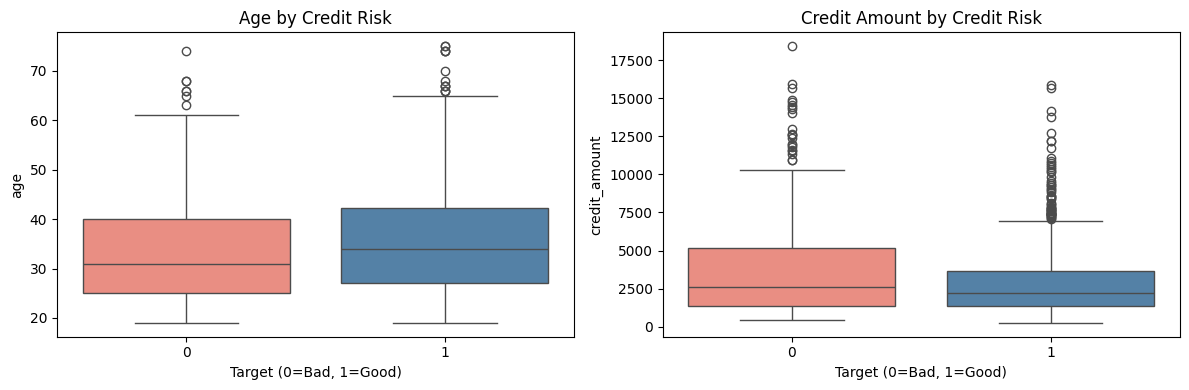

---- Median by Target ----
         age  credit_amount  duration
target                               
0       31.0         2574.5      24.0
1       34.0         2244.0      18.0


In [11]:
#Age and credit amount by target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='target', y='age', data=df, ax=axes[0], palette=['salmon', 'steelblue'])
axes[0].set_title('Age by Credit Risk')
axes[0].set_xlabel('Target (0=Bad, 1=Good)')

sns.boxplot(x='target', y='credit_amount', data=df, ax=axes[1], palette=['salmon', 'steelblue'])
axes[1].set_title('Credit Amount by Credit Risk')
axes[1].set_xlabel('Target (0=Bad, 1=Good)')

plt.tight_layout()
plt.show()

# Print the exact median values — clearer than reading off the chart
print("---- Median by Target ----")
print(df.groupby('target')[['age', 'credit_amount', 'duration']].median().round(2))

These box plots compare the distribution of each numerical feature between good and bad credit customers. I wanted to see where the two groups actually differ, since those differences are what the model will pick up on during training.<br>
A few things I looked for specifically:<br>
**Age:** if the median age for bad customers sits lower than for good customers, that's a signal that younger applicants carry more risk in this dataset. That's useful to know, but it also immediately raises a flag. Age is a protected characteristic in many jurisdictions, so if it turns out to be a strong predictor, I'll need to think carefully about fairness implications later.<br>
**Credit amount:** if bad customers tend to have higher median loan amounts, that suggests larger loans correlate with higher default risk. Not surprising, but good to confirm in the data rather than just assume.

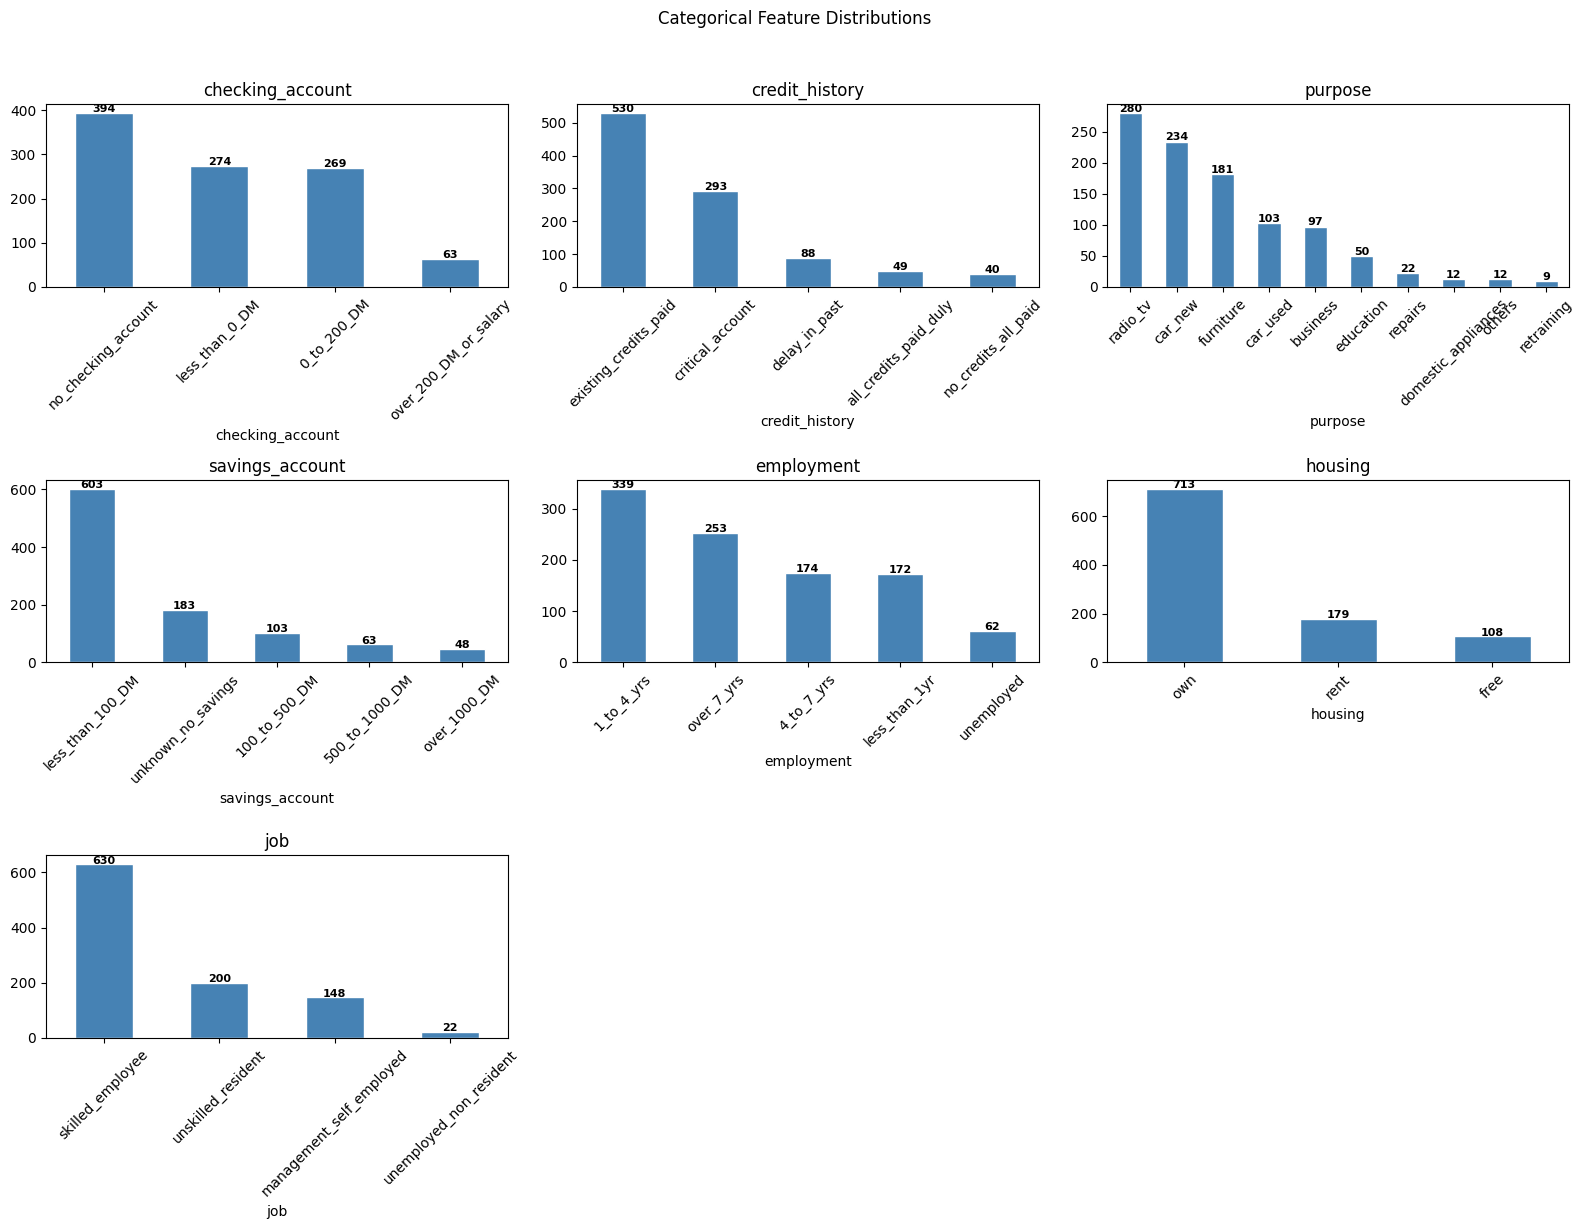

In [12]:
#Categorical features: top ones by count
categorical_cols = ['checking_account', 'credit_history', 'purpose', 
                    'savings_account', 'employment', 'housing', 'job']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add count on each bar
    for j, v in enumerate(counts):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=8, fontweight='bold')

# Hide the 2 empty subplots (we have 7 cols but 9 spaces in a 3x3 grid)
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.suptitle('Categorical Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

These bar charts show how customers are spread across the categories in each categorical feature. I wanted to understand the makeup of the population before building anything, since that directly affects what the model will and won't be good at.

A few things I paid attention to:

**Checking account:** a high proportion of "no checking account" responses is a meaningful signal on its own. Customers without a checking account are often considered higher risk, so if that category dominates, it shapes the risk profile of the whole dataset.

**Credit history:** I looked at what share of customers had critical accounts or past payment delays. A large proportion there would tell me this is a dataset skewed towards riskier applicants, which matters for how I interpret the model's outputs.

**Purpose:** it's useful to know what people are actually borrowing for. The split between everyday purchases like radio/TV versus bigger commitments like cars or business loans tells me something about the nature of credit decisions this model is being trained to make.

**Savings account:** a high proportion of customers with no savings is a portfolio-level risk signal. It means the model is being trained on a population that's already financially thin, which could affect how it generalises.

The governance angle here is something I took seriously. These distributions describe the population the model was built on, and that's a fact I have to document. If 80% of applicants in the training data are skilled employees, then the model simply hasn't seen enough unemployed applicants to handle them reliably. That's a model limitation, and SR 11-7 requires me to call it out explicitly rather than pretend the model works equally well for everyone.

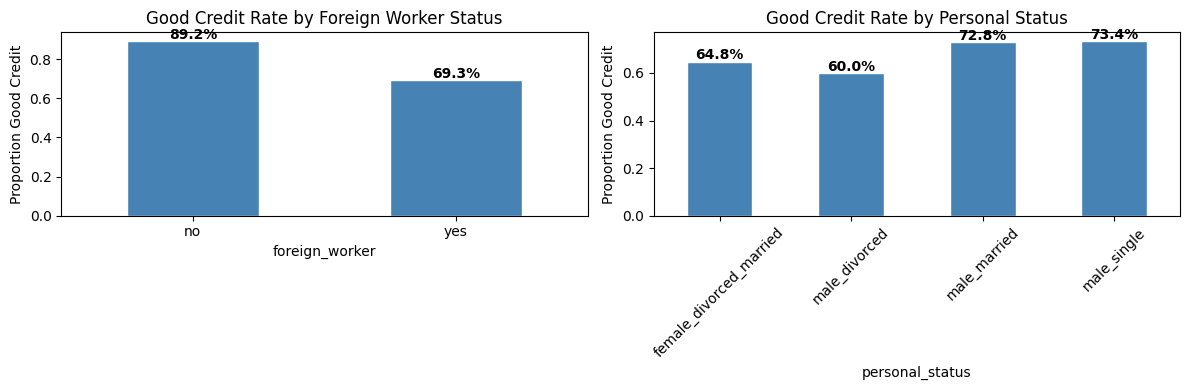

---- Good Credit Rate by Foreign Worker ----
foreign_worker
no     0.892
yes    0.693
Name: target, dtype: float64

---- Good Credit Rate by Personal Status ----
personal_status
female_divorced_married    0.648
male_divorced              0.600
male_married               0.728
male_single                0.734
Name: target, dtype: float64


In [13]:
#Fairness preview: foreign worker and personal status vs target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1 - Foreign worker
fw_rates = df.groupby('foreign_worker')['target'].mean().round(3)
fw_rates.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Good Credit Rate by Foreign Worker Status')
axes[0].set_ylabel('Proportion Good Credit')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(fw_rates):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Chart 2 - Personal status
ps_rates = df.groupby('personal_status')['target'].mean().round(3)
ps_rates.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Good Credit Rate by Personal Status')
axes[1].set_ylabel('Proportion Good Credit')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(ps_rates):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print exact rates
print("---- Good Credit Rate by Foreign Worker ----")
print(df.groupby('foreign_worker')['target'].mean().round(3))
print("\n---- Good Credit Rate by Personal Status ----")
print(df.groupby('personal_status')['target'].mean().round(3))

This table shows the average good credit rate for each group, so basically what proportion of customers in each category ended up being classified as good credit risk.

Here's what the numbers actually showed:

**Foreign worker:** non-foreign workers had a good credit rate of 89.2%, compared to 69.3% for foreign workers. That's a gap of nearly 20 percentage points, which is hard to ignore.

**Personal status:** male single and male married customers had good credit rates of 73.4% and 72.8% respectively, while female divorced/married customers came in at 64.8% and male divorced at 60.0%.

The foreign worker gap in particular is significant enough that I can't just note it and move on. Under the EU AI Act, credit scoring is classified as a High Risk AI use case, which means I'm required to assess and document fairness across protected groups, not just report accuracy.

The key question I need to answer is whether these differences are driven by genuine financial risk factors in the data, or whether the model is picking up something else, a proxy for discrimination rather than actual creditworthiness. A lower approval rate for foreign workers might reflect real differences in the features the model was trained on, or it might reflect historical bias baked into the training data. I can't tell yet just from this table, but I've flagged it and I'll be coming back to this when I get to the formal fairness analysis.

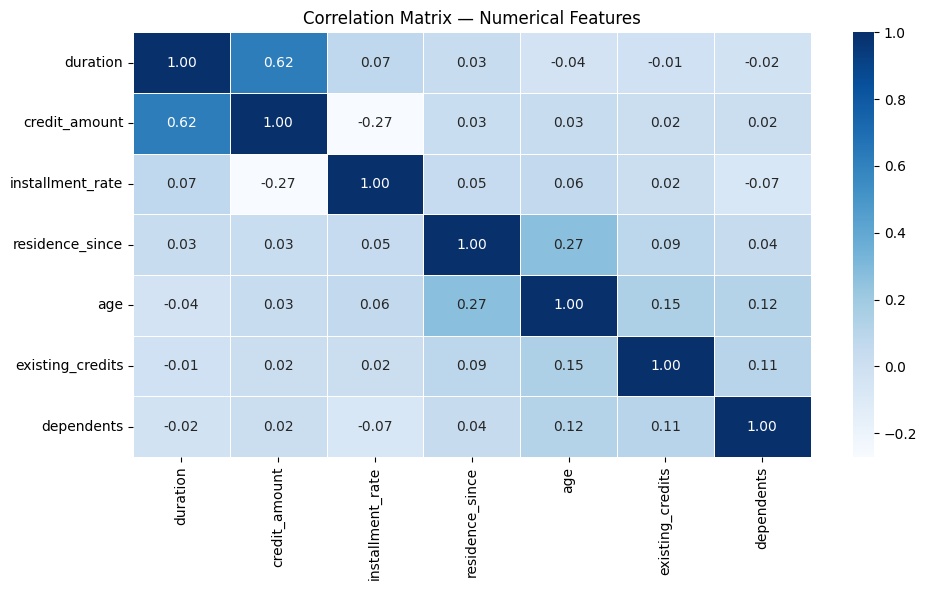

---- Correlations above 0.3 ----
  Feature 1      Feature 2  Correlation
0  duration  credit_amount     0.624984


In [14]:
#Correlation heatmap (numerical only)
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', 
            cmap='Blues', linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

# Print the strongest correlations
import numpy as np
corr_matrix = df[numerical_cols].corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
meaningful = upper.stack().reset_index()
meaningful.columns = ['Feature 1', 'Feature 2', 'Correlation']
meaningful = meaningful[abs(meaningful['Correlation']) > 0.3].sort_values('Correlation', ascending=False)
print("---- Correlations above 0.3 ----")
print(meaningful)

The correlation matrix shows how strongly pairs of numerical features move together, on a scale from -1 to +1.

A quick way to read it: values close to +1 mean both features tend to rise together, values close to -1 mean one goes up as the other goes down, and values near 0 mean there's no real relationship between them.

Only one pair came back above the 0.3 threshold I was checking for:

**Duration and credit amount: 0.625** - so longer loans do tend to be larger loans. That makes intuitive sense. Someone borrowing a small amount probably pays it back quickly, while larger loans are spread over longer terms.

Everything else was weakly correlated, which is actually good news for a logistic regression model. Weak correlations between features mean each one is contributing something independent, rather than several features all saying the same thing in slightly different ways.

The governance concern I was watching for here is multicollinearity, which is what happens when two features are so strongly correlated (above 0.8 is the usual threshold) that including both of them doesn't add much information but does add complexity and instability to the model. SR 11-7 requires me to justify my feature selection, so if I had found a pair above 0.8, I'd have needed to either drop one or explicitly explain why I kept both. The duration and credit amount pair at 0.625 is worth keeping an eye on, but it's not at a level that forces a decision right now.

In [15]:
#Summary statistics
print("---- Dataset Shape ----")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n---- Class Balance ----
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

print("\n---- Missing Values ----
print(df.isnull().sum().sum(), "missing values total")

print("\n---- Numerical Summary ----
print(df[numerical_cols].describe().round(2))

print("\n---- Dominant Category per Feature ----")
for col in categorical_cols:
    top = df[col].value_counts().index[0]
    count = df[col].value_counts().values[0]
    pct = round(count / len(df) * 100, 1)
    print(f"{col}: '{top}' — {count} ({pct}%)")

SyntaxError: EOL while scanning string literal (1010416832.py, line 5)

## EDA : Key Takeaways

**Data prep:** Decoded all coded values ('A93' to 'male_single', etc.) before any analysis. Non-negotiable for interpretability and fairness work.

**Class imbalance:** 70% good, 30% bad. Accuracy is off the table as a primary metric.

**Distributions:** Duration and credit amount are right-skewed with high-end outliers. Age peaks around 30-40. These go into the model documentation.

**Feature separation:** Younger applicants and larger loan amounts appear more often in the bad credit group. Age as a predictor immediately raises a fairness flag.

**Categorical gaps:** Sparse representation in some groups (unemployed, no savings) means the model may not generalise well to them. A limitation I need to document under SR 11-7.

**Bias signals:** Foreign workers approved at 69.3% vs 89.2% for non-foreign workers. Female divorced/married customers at 64.8% vs 73.4% for male single. Needs deeper investigation before model sign-off.

**Multicollinearity:** Only duration and credit amount correlated meaningfully (0.625). No action needed yet.

**Cost matrix:** False negatives cost 5x more than false positives. Evaluation will need to reflect this asymmetry, not just optimise for accuracy.